# Supervised metrics

The `sp` (supervised) module provides metrics to evaluate how well cell profiles in a spatial transcriptomics dataset agree with a reference single-cell RNA-seq (scRNA-seq) dataset with cell type annotations.

Unlike scRNA-seq, spatial transcriptomics measurements are affected by the local tissue context. Transcripts can be captured outside their cell of origin due to transcript diffusion, 3D overlap, or segmentation inaccuracies, leading to mixed or contaminated expression profiles. As a result, spatial cells may partially resemble their neighbors.

By comparing spatial expression profiles to a high-quality scRNA-seq reference, the supervised module aims to quantify this mismatch. Specifically, we use the scRNA-seq dataset as a clean reference, transfer cell type labels to the spatial data, and then compute metrics that measure:
- how well each spatial cell matches its expected cell type, and
- how much its expression resembles other (neighboring) cell types.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
import segtraq

#### Transfer labels from scRNA-seq to spatial transcriptomics

We first load a spatial transcriptomics dataset (stored as a `SpatialData` object) and an annotated scRNA-seq reference dataset (stored as an `AnnData` object). For demonstration purposes, we subset the spatial dataset to a smaller region to reduce runtime.

Next, we initialize a `SegTraQ` object from the SpatialData. During initialization, the `validate_spatialdata()` method is automatically run to ensure that all required attributes (e.g. `images_key`, `tables_key`) are correctly specified.

We then transfer cell type labels from the scRNA-seq reference to the spatial dataset using `run_label_transfer()`. This method computes cell type–specific mean expression profiles in the reference and assigns each spatial cell to the cell type with the highest Pearson correlation to its expression profile.

Finally, we define a color scheme for visualizing the transferred cell type labels.

In [27]:
# Load spatial transcriptomics dataset 
sdata_ws = sd.read_zarr("../../data/xenium.zarr/")

# Subset the dataset to a specific bounding box
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

sdata = sdata_ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

# initialize SegTraQ object
st = segtraq.SegTraQ(
    sdata, 
    images_key="image", 
    tables_centroid_x_key="x_centroid", 
    tables_centroid_y_key="y_centroid"
    )

# st = segtraq.SegTraQ(
#     sdata,
#     images_key="image",
#     points_background_id=0,
#     tables_centroid_x_key="centroid_x",
#     tables_centroid_y_key="centroid_y",
#     tables_area_volume_key="volume",
# )

# Load scRNA-seq dataset
scRNAseq_data_path = Path("../../data/BC_scRNAseq_Janesick.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

# Define color palette for cell types
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

/tmp/ipykernel_2641607/3372919038.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata_ws = sd.read_zarr("../../data/xenium.zarr/")
no parent found for <ome_zarr.reader.Label object at 0x7ffe241fc450>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe24202c50>: None


/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: Missing 8 cell IDs in tables: ['aphffbmb-1', 'aphemnlm-1', 'apnfcbpf-1', 'icdokine-1', 'iceeeemj-1']... These cells are present in shapes, but not in tables. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(


The transferred labels are stored in  
`sdata.tables[tables_key].obs["transferred_cell_type"]`.  
The column name can be changed via the `cell_type_key` argument.

By default, cells with **≤ 10 or ≥ 2000 transcripts** and **≤ 5 detected genes** are filtered out.  
These thresholds can be adjusted using `tx_min`, `tx_max`, `gn_min`, and `gn_max`.

Ensure that gene identifiers match between `adata_ref.var_names` and  
`sdata.tables[tables_key].var_names`. If they differ, specify the corresponding
identifier columns using `ref_ensemble_key` and `query_ensemble_key`.  
If these are left as `None` (default), `var_names` are used.

In [28]:
st.run_label_transfer(
    adata_ref, 
    ref_cell_type="celltype_major", # Reference cell type column
    ref_ensemble_key=None, 
    query_ensemble_key=None)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:385: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:346: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["raw"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:428: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_q.layers["raw"] = adata_q.X


Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [29]:
# Replace NaN with Unknown
s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_cell_type_plot"] = s.fillna("Unknown")

labels = st.sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_2641607/964490482.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


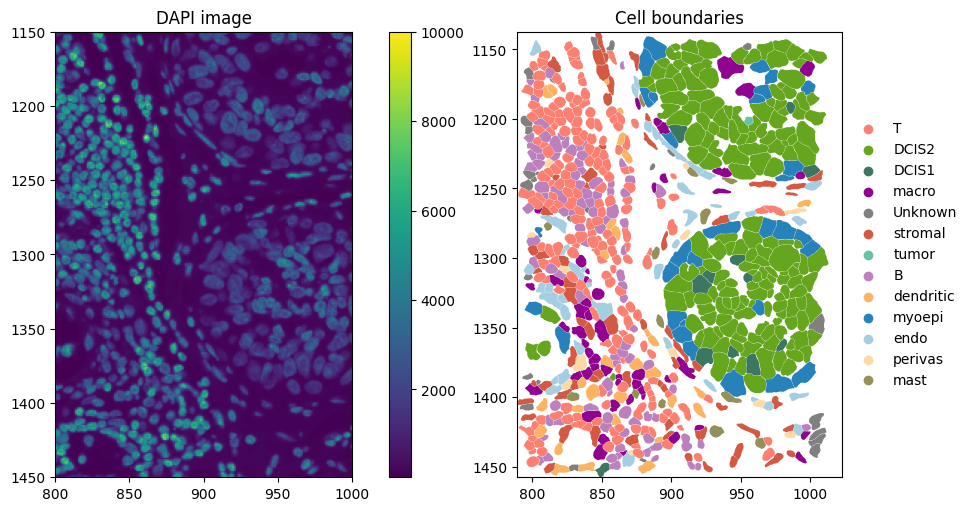

In [30]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
st.sdata.pl.render_images(
    "image"
).pl.show(ax=axes[0], 
          title="DAPI image", 
          coordinate_systems="global"
          )

# Add link between table and spatial element
st.sdata.tables["table"].obs["region"] = "cell_boundaries"
st.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries", coordinate_systems="global")

Spatial data are normalized and log transformed for some of the metrics below. The raw counts will be saved in `sdata.tables[tables_key].layers["raw]`.

In [31]:
tables_key = "table" #adjust as needed"

adata = st.sdata.tables[tables_key]
# Store raw counts
adata.layers["raw"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


#### Computing cell type-specific markers

**Positive markers** are genes that are consistently upregulated in one cell type relative to other cell types. To avoid composition bias arising from unequal cell type abundances, we perform **pairwise comparisons between all cell types** in the reference dataset. Marker detection can be performed using either differential expression (`mode="de"`) or AUC-based scoring (`mode="auc"`).  

For each cell type, genes are selected by a voting scheme: a gene must be identified as upregulated in at least a fraction of pairwise contrasts (`vote_fraction_pos`, default = 0.3). To further increase specificity, we require that a positive marker is not shared by more than `t_pos × n_celltypes` cell types. This yields markers that are both upregulated and cell-type–specific, without bias from cell type composition in the reference data.

**Negative markers** are derived from the positive markers. A gene is considered a negative marker for a given cell type if it is expressed (`> 0`) in at most a fraction of cells of that type (`vote_fraction_neg`, default = 0.05) and is not a positive marker of that cell type. Importantly, negative markers are not downregulated genes, but genes that are *off* in the focal cell type while being positive markers for other cell types. This property makes them informative for evaluating contamination and purity of spatial cell expression profiles.

When using `mode="auc"`, the minimum required AUC can be set via `auc_pos_thresh` (default = 0.9).  
When using `mode="de"`, the differential expression method can be selected via `method` (`"wilcoxon"`, `"t-test"`, or `"logreg"`), with thresholds defined by `logFC_pos_thresh` (default = 1.0) and `pval_adj_thresh` (default = 0.05).  

All computations can be parallelized by specifying the number of jobs via `n_jobs`.

Only genes common to the scRNA-seq and spatial transcriptomics dataset will be considered to reduce compute time.

In [32]:
# subsetting to commong genes
common_genes = adata.var_names[adata.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [40]:
# get cell type-specific markers from the reference dataset
markers = segtraq.get_ref_markers(adata_ref, 
                                  mode = "de",
                                  vote_fraction_pos = 0.5,
                                  vote_fraction_neg = 0.05,
                                  ref_cell_type="celltype_major", 
                                  n_jobs = 16)

A list of positive and negative markers computed for each cell type is shown below. 

In [10]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]
    
    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: MS4A1, BANK1, CD79A, PARP15, TNFRSF13B, BLK, TNFRSF13C, POU2AF1, AIM2, PAX5, FCRL1, CD79B, FCRL2, ST6GAL1, P2RX5, POU2F2, PTPN6, CD19, FCRL5, SCIMP, ADAM28, FCMR, NIBAN3, CR1, SP110, CDK14, TLR6, ITGB7, KCNN4, CD27, SMCHD1, SPIB, DERL3, STAP1, FCRLA, NCOA3, COL4A3, FCRL3, ANKRD13A, CD40, CCDC141, ZBP1, PIM2, COL4A4, TNFRSF17, IRF4, CNR2, SYVN1, CD38, CCR6, SLAMF6, CYSLTR1, COCH, CXCR5, CCDC50, PNOC, ANGPTL6, SIGLEC6, BCL2, PDK1, INPP5D, TRAF5, NLRC5, CASP10, KCNA3, ATP2B1, SLAMF1, TLR1, FCGR2B, GPR174, BTN3A1, CLNK, CD1C, FCER2, CD72, CNR1
B  |  negative: AAR2, ABCA10, ABCA8, ABCB1, ABCC12, ABCC8, ABI3BP, ABO, ABTB2, AC007906.2, ACPP, ACVRL1, ADAM12, ADAM33, ADAMDEC1, ADAMTS14, ADAMTS5, ADAMTSL3, ADCYAP1, ADCYAP1R1, ADGRB1, ADGRD1, ADGRD2, ADGRE2, ADGRG6, ADGRL4, ADM, ADORA2B, ADORA3, ADRA1B, ADRA2A, ADTRP, AGMAT, AHRR, AIF1, AKR1C3, ALDH7A1, ALPL, ANGPT1, ANGPTL2, ANGPTL4, ANXA3, ANXA8, AOC3, AOX1, AP3B2, APCDD1, APLNR, ARL4D, ART4, ASPN, ATL1, ATOH8, ATP6V1B1, AUNIP, 

Below, we show the number of negative markers that overlap with the positive markers of each cell type.  
To reliably estimate contamination, each cell type should share **at least ~5 negative markers** with the positive marker set of every other cell type. If these overlaps are too small, contamination estimates become unstable.

In such cases, the marker definition can be relaxed by adjusting the thresholds used in `get_ref_markers` above.


In [42]:
ctypes = list(markers.keys())
overlap_df = pd.DataFrame(0, index=ctypes, columns=ctypes, dtype=int)

for c in ctypes:
    neg_c = set(markers[c].get("negative", []))
    for d in ctypes:
        pos_d = set(markers[d].get("positive", []))
        overlap_df.loc[c, d] = len(neg_c & pos_d)

overlap_df

,B,DCIS1,DCIS2,T,dendritic,endo,macro,mast,myoepi,perivas,stromal,tumor
B,0,81,98,40,43,146,127,23,194,38,151,139
DCIS1,55,0,45,62,54,128,124,23,103,30,121,47
DCIS2,54,35,0,65,52,121,119,24,125,32,125,22
T,47,156,180,0,66,173,170,26,214,47,166,286
dendritic,36,75,99,42,0,135,90,18,173,37,132,143
endo,48,65,65,54,41,0,110,20,117,9,78,95
macro,37,74,95,40,37,129,0,16,162,37,129,132
mast,58,185,208,82,78,176,158,0,215,41,172,338
myoepi,51,20,32,49,44,95,89,17,0,24,90,49
perivas,55,71,79,49,49,83,129,23,131,0,87,111


#### Compute marker purity

We next quantify how *pure* each spatial cell’s expression profile is with respect to its assigned cell type using positive and negative marker genes.

We assume that differences between scRNA-seq and spatial transcriptomics profiles arise primarily from **local contamination by neighboring cells** (e.g. diffusion or segmentation spillover). This motivates evaluating negative markers in a **neighborhood-aware** manner.

**Identity evaluation**  
For each cell of type `c`, we compute per-cell precision, recall, and F1 based on `markers[c]["positive"]`. These scores measure how consistently a cell expresses markers expected for its assigned type. Marker presence is defined either by a rank-based quantile rule (`use_quantiles=True`, default) or by expression `> 0`.

**Contamination (neighborhood-aware).**  
For a focal cell, we identify the cell types present in its spatial neighborhood and intersect the focal cell type’s negative markers with the positive markers of neighboring cell types. Optionally, these markers can be further restricted to genes that are expressed in at least one neighboring cell of the corresponding source type (`require_neighbor_expression = True`). These *relevant negative markers* represent genes that should be absent from the focal cell but present in nearby cells. Precision, recall, and F1 then quantify how well the focal cell avoids expressing neighborhood-associated markers.

If no neighborhood graph is present (`neighbors_key not in sdata.tables[tables_key].obsp`), it is automatically computed from cell centroids using a Delaunay graph.

**Overall purity.**  
Positive and negative F1 scores are combined into a single `F1_purity` score, optionally with a weighting factor for `negative_F1` (`weight_cont`, default=2.0). High purity indicates strong expression of cell-type–specific markers and minimal expression of markers attributable to neighboring cells. 

All per-cell metrics are returned and, if `inplace=True`, stored in `sdata.tables[tables_key].obs`.


In [43]:
purity =st.sp.calculate_marker_purity(
    cell_type_key="transferred_cell_type", 
    markers=markers,
    weight_cont=0.7,
    require_neighbor_expression=True,
    neighbors_key="spatial_connectivities",
    use_quantiles=False,
    inplace=True)

##### `negative_F1`

In [13]:
def boxplot_per_celltype(
    sdata,
    feature,
    celltype_col="transferred_cell_type",
    q=1.0,
    figsize=(10, 5),
    palette=None,
):
    obs = sdata.tables["table"].obs
    df = obs[[celltype_col, feature]].dropna().copy()

    if q < 1:
        df = df[df[feature] <= df[feature].quantile(q)]

    # order by median (low -> high). Use .sort_values(ascending=False) for high -> low
    order = (
        df.groupby(celltype_col)[feature]
          .median()
          .sort_values()
          .index
          .tolist()
    )

    # ensure palette covers all categories (optional safety)
    if palette is not None:
        palette = {ct: palette.get(ct, "#808080") for ct in order}

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x=celltype_col,
        y=feature,
        order=order,
        hue=celltype_col,
        palette=palette,
        showcaps=True,
        showfliers=False,
        legend=False,
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x=celltype_col,
        y=feature,
        order=order,
        hue=celltype_col,
        palette=palette,
        jitter=0.25,
        dodge=False,
        alpha=0.6,
        edgecolor="black",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Cell type")
    ax.set_ylabel(feature)
    fig.tight_layout()
    plt.show()


The `negative_F1` score indicates that cells of type DCIS1 are the most contaminated.

/tmp/ipykernel_2641607/2467939028.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(celltype_col)[feature]


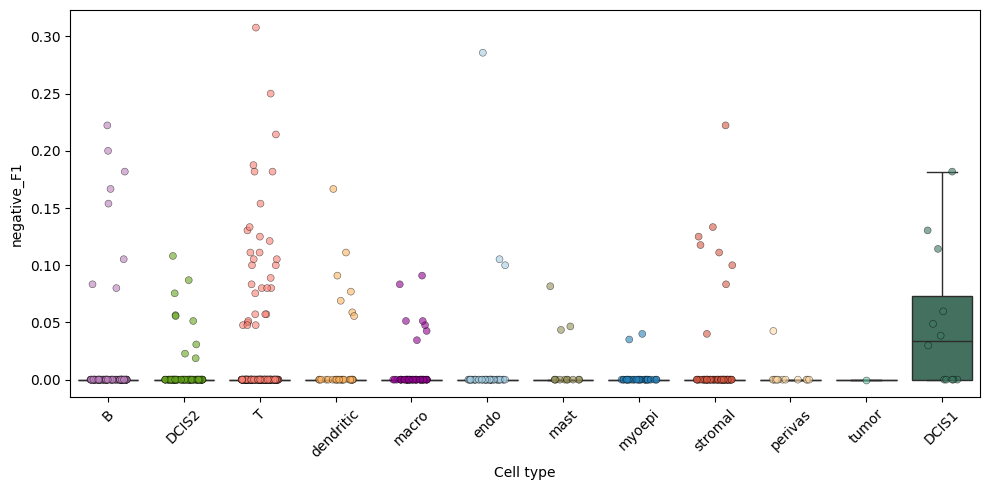

In [44]:
boxplot_per_celltype(st.sdata, 
                     feature = "negative_F1",
                     palette=col_celltype
                     )

This can also be visualized spatially. The `negative_F1` score is only computed for cells which have a neigbhor of a different type. This clearly shows the DCIS1 cells with high `negative_F1` score, i.e. contamination.

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 143 NaN values in color data. These observations will be colored with the 'na_color'.               


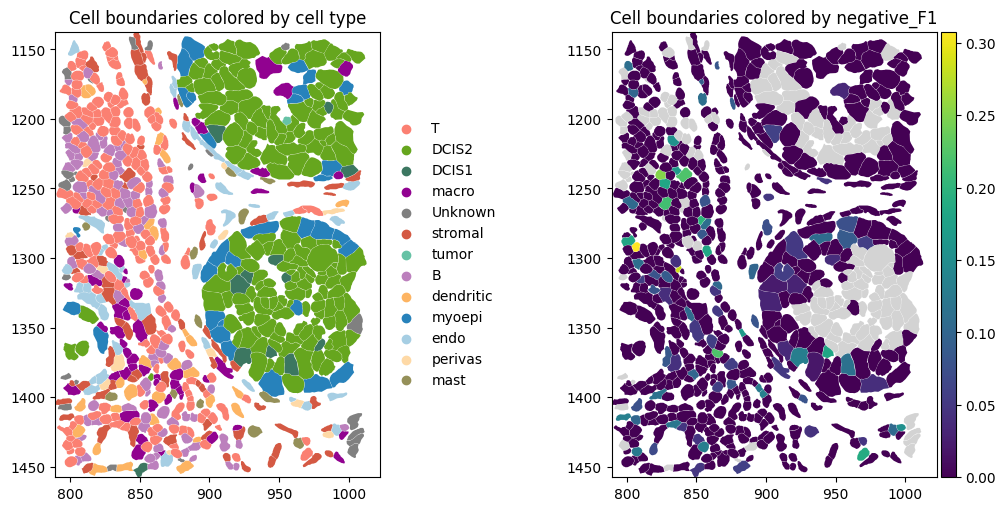

In [45]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="negative_F1",
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by negative_F1", coordinate_systems="global")

##### `positive_F1`

Cells annotated as mast and DCIS2 show the highest `positive_F1` scores, suggesting that their cell identity is captured most consistently by positive markers. 

/tmp/ipykernel_2641607/2467939028.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(celltype_col)[feature]


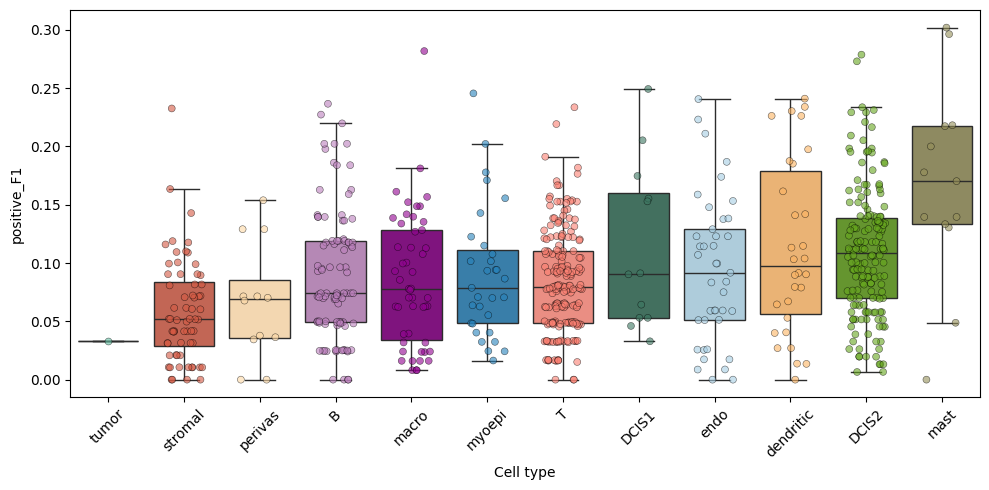

In [46]:
boxplot_per_celltype(st.sdata, 
                     feature = "positive_F1",
                     palette=col_celltype
                     )

The `positive_F1`score is computed globally, i.e. irrespective of the cell neighborhood, so there are fewer missing values than for `negative_F1`. The spatial plot below is in line with the boxplot above, showing that cells of type DCIS2 and mast show the highest `positive_F1`.

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 26 NaN values in color data. These observations will be colored with the 'na_color'.                


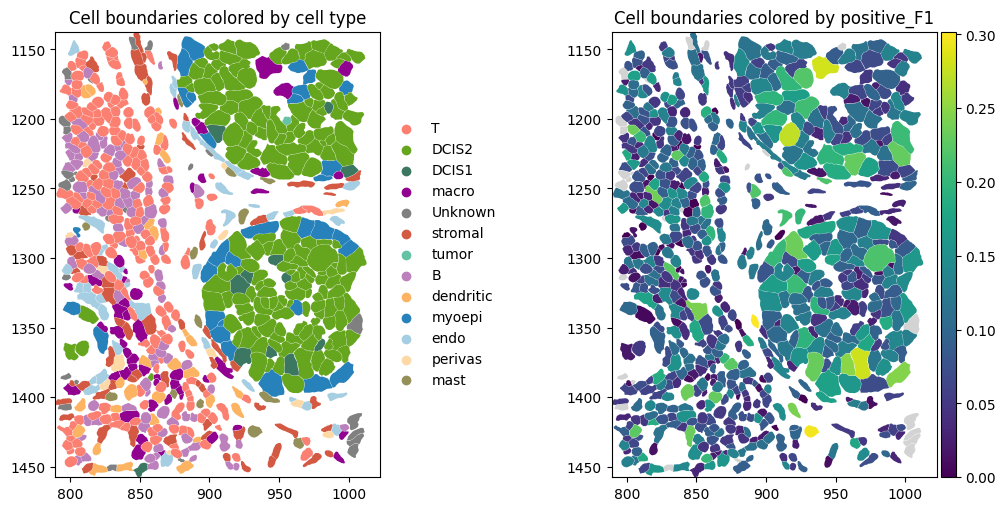

In [47]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="positive_F1",
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by positive_F1", coordinate_systems="global")

##### `F1_purity`

Cells of type **DCIS1** (which have high transcript counts) show the highest `negative_F1` and the fourth-highest `positive_F1`. This is expected: cells with higher transcript counts tend to capture more positive markers, but also have a higher risk of capturing negative markers. As a result, the combined metric `F1_purity`, which balances `positive_F1` and `negative_F1`, provides a more representative measure of purity. Accordingly, **DCIS1** ranks among the cell types with the lowest purity, while **DCIS2** and **mast** cells show the highest purity.

/tmp/ipykernel_2641607/2467939028.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(celltype_col)[feature]


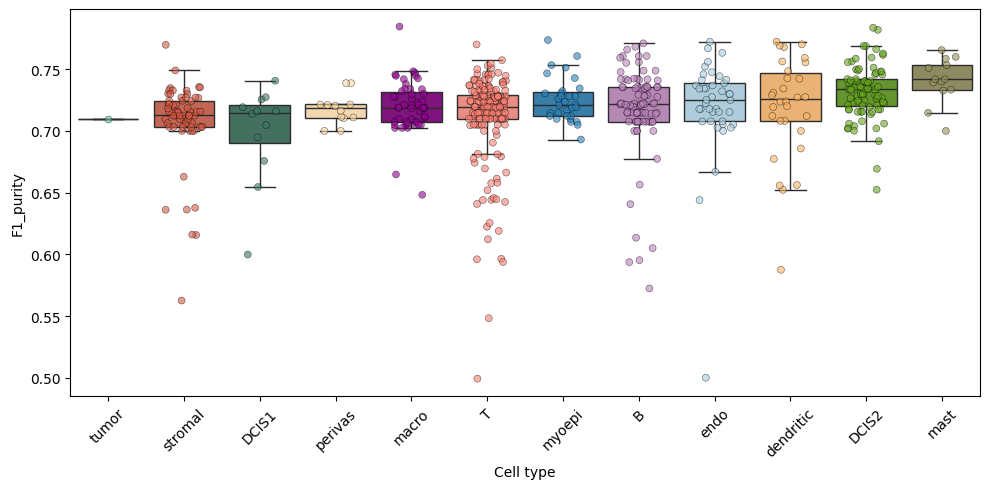

In [48]:
boxplot_per_celltype(st.sdata, 
                     feature = "F1_purity",
                     palette=col_celltype
                     )

#### Neighborhood contamination

Marker purity summarizes how well a cell matches its own markers and avoids neighborhood-relevant negatives. In many cases, we also want to quantify (i) **how many contaminating transcripts** are present per cell and (ii) **which neighboring cell types** contribute to this signal. We therefore compute neighborhood contamination.

We treat a gene as contamination-relevant for a target cell type `c_tgt` if it is (i) a **negative marker of `c_tgt`**, (ii) simultaneously a **positive marker of a neighboring source type `c_src`**, and (iii) actually **expressed (>0) in at least one of the neighboring cells of the source type** (`require_neighbor_expression` , default=True).

This yields two levels of output:

**Per-cell metrics.**
For each cell, we compute
- `neg_marker_contam_counts`: the total number of transcripts for contamination-relevant genes, and
- `neg_marker_contam_fraction`: a gene-wise average of  
  `x_i(g) / (x_i(g) + mean_neighbor(g))`,  
  which measures how much of the shared marker signal is assigned to the focal cell rather than to its neighborhood.

**Directed cell-type contamination (stored in `.uns`):**
By aggregating across cells, we construct
- `uns_key`: a directed **source → target** matrix where each entry is the average strength of contamination from one cell type into another, and
- `uns_key_binary`: a complementary directed matrix that reports what percentage of cells of a target type is contaminated by each source type.

If no neighborhood graph is present (`neighbors_key not in sdata.tables[tables_key].obsp`), it is automatically computed from cell centroids using a Delaunay graph.

In [49]:
per_cell_df, cont_mat, cont_bin =st.sp.calculate_neighbor_contamination(
    cell_type_key="transferred_cell_type",
    markers=markers,
    require_neighbor_expression=True,
    neighbors_key="spatial_connectivities",
    uns_key="negative_marker_contamination",
    uns_key_binary="negative_marker_contamination_binary",
    inplace=True,
)

##### `neg_marker_contam_counts`

The spatial plot below shows, for each target cell, the number of contaminating transcripts. If desired, this quantity can be normalized by the total number of transcripts per cell. As expected, the plot correlates with the `negative_F1`score from above.

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


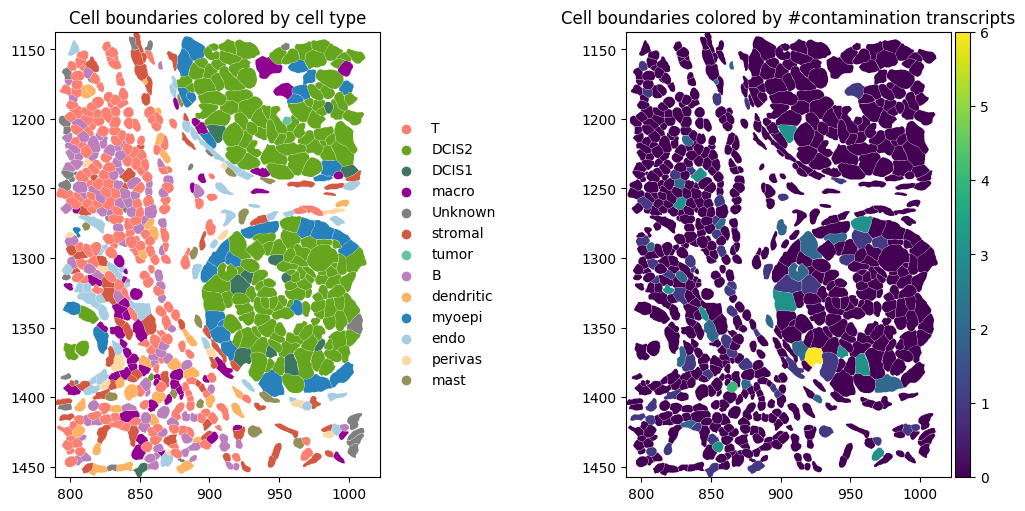

In [50]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="neg_marker_contam_counts",
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by #contamination transcripts", coordinate_systems="global")

##### `neg_marker_contam_fraction`

In addition, we can plot `neg_marker_contam_fraction`, the fraction of the signal that is "living" in the wrong cell instead of in the neighbors. 

Relevant only if `require_neighbor_expression` = `False`: `neg_marker_contam_fraction`=1 means that 100% of the signal lives in the wrong cell. 

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 657 NaN values in color data. These observations will be colored with the 'na_color'.               


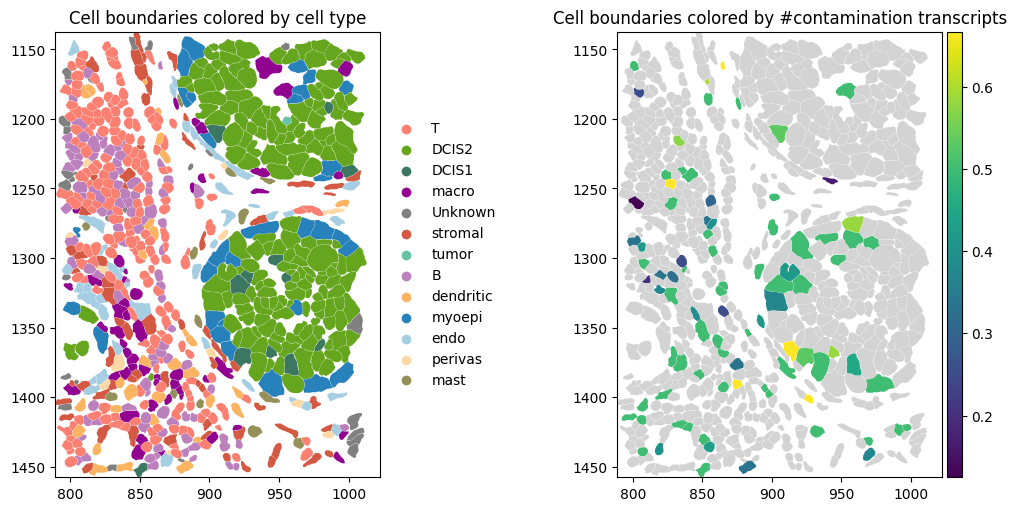

In [51]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="neg_marker_contam_fraction",
    outline_color="white",  
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by #contamination transcripts", coordinate_systems="global")

##### `.uns["contam_binary_df"]`

The heatmap below shows, for each source–target cell-type pair, the **fraction of all target cells** contaminated by transcripts from a neighboring source cell type.

Percentages within a column may sum to more than 100% because a single target cell can be contaminated by **multiple** neighboring source cell types and is therefore counted for each of them.

DCIS1 cells are mostly contaminated by DCIS2 cells, which makes sense since they are frequent neighbors. T cells are contaminated by stromal and B cells.

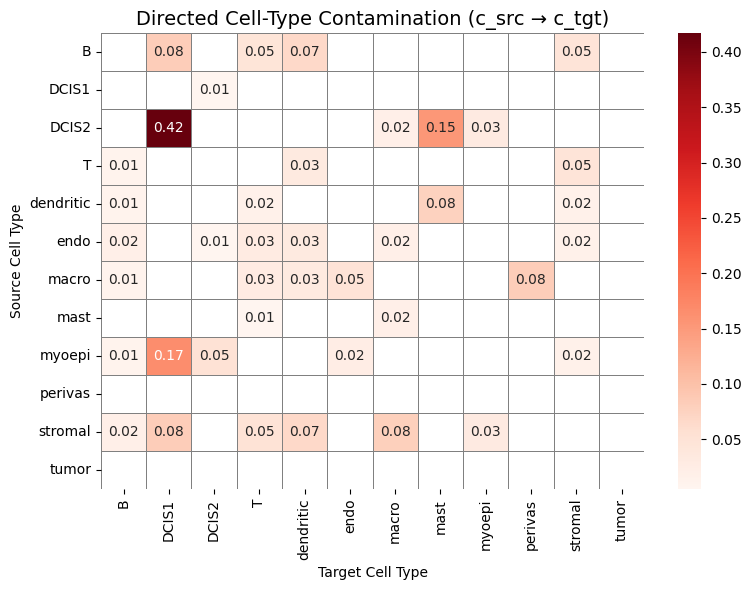

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cont_bin,
    annot=True,
    fmt=".2f",
    cmap="Reds",       # or "viridis", "magma", "rocket"
    linewidths=0.5,
    linecolor="gray"
)
plt.title("Directed Cell-Type Contamination (c_src → c_tgt)", fontsize=14)
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.tight_layout()
plt.show()


##### `.uns["contam_matrix_df"]`

The heatmap below reports, for each source–target cell-type pair, the **mean contamination fraction** aggregated across all contributing cells and genes.  
Each entry corresponds to the average value of fraction of the signal that is "living" in the wrong cell (source cell) instead of in the neighbors (target cell).

Relevant only if `require_neighbor_expression` = `False`: Values close to **1** indicate cases where the target cell carries most or all of the detected signal for a given gene, while neighboring source cells show little or no expression of that gene. This typically reflects rare or low-count events, such as single-transcript misassignments.


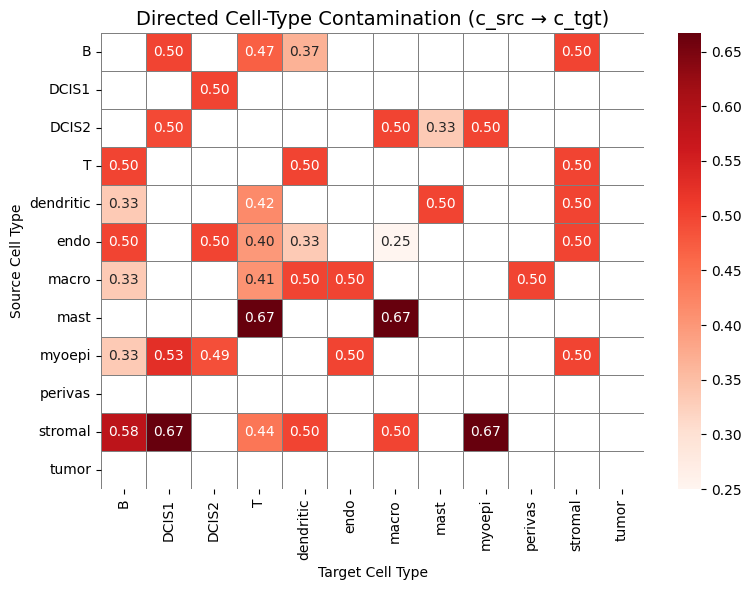

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cont_mat,
    annot=True,
    fmt=".2f",
    cmap="Reds",       # or "viridis", "magma", "rocket"
    linewidths=0.5,
    linecolor="gray"
)
plt.title("Directed Cell-Type Contamination (c_src → c_tgt)", fontsize=14)
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.tight_layout()
plt.show()

#### Differential expression between adjacent and non-adjacent cell types

To assess the effect of spillover, we can do a differential expression test between cells one cell type bordering another cell type vs. those not bordering that cell type. For example, consider all B cells. We now want to know if B cells that are close to T cells have a different expression profile to B cells which are not next to any T cells.

The algorithm works as follows:
- Construct a neighborhood graph (Delaunay)
- for every marker, ct1 and ct2:
    - get all cells of ct1
    - subset them into those that are next to cells of ct2 (group1) and those that are not next to cells of ct2 (group2)
    - Only continue if there are at least 20 cells in each group
    - do a differential expression test between the groups (Wilcoxon rank-sum on normalized and log-transformed counts)
    - Remove genes which have less than 20 transcripts in both groups combined
    - Only keep genes that are supposed to be negative in ct1 and positive in ct2
- result: for each (gene, ct1, ct2), we get a log fold change and a p-value

A couple of important things to note here:
- we only look at genes that are negative in the "receiver" cell type, and positive in the "sender" cell type (from which the spillover originates). We use the definition of "negative" and "positive" markers from earlier
- since we specifically want to look at spillover events, we only look at genes with a high log fold change (LFC), and ignore the ones with a low LFC

In [26]:
sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/xenium.zarr
├── Images
│     └── 'image': DataArray[cyx] (1, 1795, 1519)
├── Labels
│     ├── 'cell_labels': DataArray[yx] (1795, 1519)
│     └── 'nucleus_labels': DataArray[yx] (1795, 1519)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (18311, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (18608, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (18311, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [ ]:
de_results, de_summary = st.sp.calculate_diff_abundance(
    markers=markers,
    pval_thresh=0.05,
    lfc_thresh=10,
    cell_type_key="transferred_cell_type",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
de_results.head()

We can start interpreting the results by looking at a volcano plot of the results. We will show all events in this plot, and color them by the receiving cell (indicated as `ct1`).

In [ ]:
# creating a volcano plot
plt.figure(figsize=(6, 5))
for ct, color in col_celltype.items():
    sub = de_results[de_results["ct1"] == ct]
    plt.scatter(sub["log2FC"], -np.log10(sub["pval"]), c=color, label=ct, alpha=0.6, s=10)
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("log2FC")
plt.ylabel("-log10(p-value)")
plt.legend(markerscale=2)
plt.title("Volcano plot of spatial DE")
plt.show()

We can also check the number of events we found with our thresholds for each sender(`ct2`)/receiver(`ct1`) pair.

In [ ]:
# sns.heatmap(de_summary)

It looks like all of our spillover is caused by DCIS2 cells spilling over into cells of another cell type. Let's visualize some of our supposed spillover events spatially.

In [ ]:
de_results.sort_values(by="log2FC", ascending=False).head()

In [ ]:
axes = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)[1]

# Plot - Cell boundaries
sdata.pl.render_shapes(
    "cell_boundaries", color="transferred_cell_type_plot", palette=["deepskyblue", "gold"], groups=["DCIS1", "DCIS2"]
).pl.render_points("transcripts", color="feature_name", groups="CLTC", palette="black").pl.show(
    ax=axes, title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)